In [1]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import ast

## __HELPER FUNCTIONS__

In [2]:
# Tsys = WALK
walk_types = {
    'unclassified', 'residential', 'service',
    'footway', 'path', 'living_street', 'pedestrian', 'track', 'steps',
    'corridor', 'bridleway', 'ladder'
}

#Tsys = CAR, BUS
car_types = {
    'motorway', 'motorway_link', 
    'trunk', 'trunk_link', 
    'primary', 'primary_link', 
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
    'unclassified', 'residential', 'service',
}

# Tsys = BIKE
bicycle_types = {'cycleway'}

# Tsys = BRT
BRT_types = {'busway'}

# Tsys = TREN LIGERO
tren_ligero_names = {
    'Línea 1 del Tren Eléctrico Urbano',
    'Linea 1 del Tren Eléctrico Urbano', 
    'Línea 2 del Tren Eléctrico Urbano',
    'Linea 2 del Tren Eléctrico Urbano',
    'Línea 3 del Tren Eléctrico Urbano',
    'Linea 3 del Tren Eléctrico Urbano',
    'Línea 4 del Tren Eléctrico Urbano de Guadalajara',
    'Linea 4 del Tren Eléctrico Urbano de Guadalajara'
}

In [3]:
def assign_mode(row):
    highway = row.get('highway_norm', [])
    name = row.get('name', '')

    # if highway is empty
    if not highway and name in tren_ligero_names:
        return 'TREN LIGERO'
    
    #Exclusive link BRT
    if set(highway) & BRT_types:
        return 'BRT'

    modes = []
    if set(highway) & bicycle_types:
        modes.append('BIKE')
    if set(highway) & car_types:
        modes.append('BUS')
        modes.append('CAR')
    if set(highway) & walk_types:
        modes.append('WALK')

    #return modes
    return ",".join(sorted(set(modes)))

In [4]:
mode_to_tsys = {
    'CAR':'C',
    'BUS':'B',
    'WALK':'W',
    'BIKE':'Bicycle',
    'BRT':'BRT',
    'TREN LIGERO':'TL',
}

def define_tsys(row):
    modes_str = row.get('Modes', '')
    modes = [m.strip() for m in modes_str.split(',')]
    tsys = [mode_to_tsys[m] for m in modes if m in mode_to_tsys]
    tsys_str = ",".join(tsys)
    return tsys_str

In [5]:
def parse_highway(val):
    if isinstance(val, str) and val.startswith('['):
        try:
            return ast.literal_eval(val)
        except Exception:
            return [val]
    elif isinstance(val, str):
        return [val]
    elif isinstance(val, list):
        return val
    else:
        return []

In [6]:
def one_way_flag(row):
    # OSMnx drive graph is directed; use simple 1/0 export
    ow = row.get("oneway", None)
    if pd.isna(ow) or ow is None:
        return 0
    if isinstance(ow, bool):
        return int(ow)
    if str(ow).lower() in ["yes", "true", "1"]:
        return 1
    return 0

## __AMG Polygon__

In [7]:
AMG_Polygon = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Importacion TransCAD/Limites Municipales/AMG/AMG_SHAPE.shp')
print("original AMG_Polygon CRS:", AMG_Polygon.crs)
AMG_Polygon = AMG_Polygon.to_crs(epsg=4326)
print("AMG_Polygon CRS after transformation:", AMG_Polygon.crs)

original AMG_Polygon CRS: EPSG:4019
AMG_Polygon CRS after transformation: EPSG:4326


## __Red Vial__

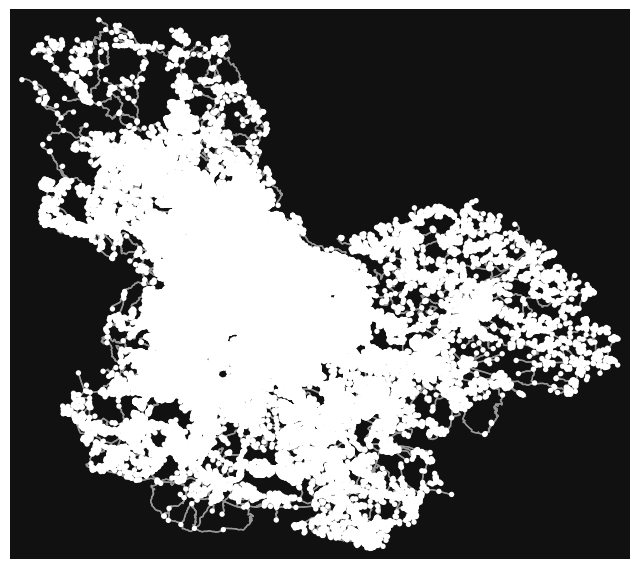

In [8]:
G_all = ox.graph_from_polygon(
    AMG_Polygon.geometry.iloc[0],
    network_type="all",
    simplify=True,
    retain_all=False,
    truncate_by_edge=False
)
fig, ax = ox.plot_graph(G_all)
nodes_vial, edges_vial = ox.graph_to_gdfs(G_all, nodes=True, edges=True)

## __Red Tren Ligero__

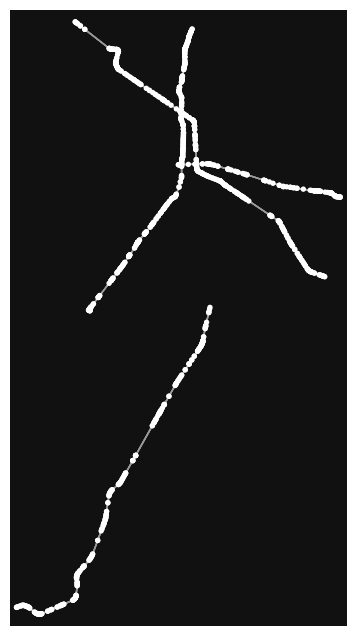

In [9]:
rail_filter = (
    '["railway"~"light_rail|subway|rail"]'
    '["name"~"Línea 1 del Tren Eléctrico Urbano|'
    'Linea 1 del Tren Eléctrico Urbano|'
    'Línea 2 del Tren Eléctrico Urbano|'
    'Linea 2 del Tren Eléctrico Urbano|'
    'Línea 3 del Tren Eléctrico Urbano|'
    'Linea 3 del Tren Eléctrico Urbano|'
    'Línea 4 del Tren Eléctrico Urbano de Guadalajara|'
    'Linea 4 del Tren Eléctrico Urbano de Guadalajara"]'
)

G_rail_uns = ox.graph_from_polygon(
    AMG_Polygon.geometry.iloc[0],
    custom_filter=rail_filter,
    simplify=False, #AQUI si false para mantener todas las estaciones
    retain_all=True, #TRUE porque las 4 lineas no estan conectadas entre si
    truncate_by_edge=False
)
fig, ax = ox.plot_graph(G_rail_uns)
nodes_rail, edges_rail = ox.graph_to_gdfs(G_rail_uns, nodes=True, edges=True)

## __Red Base (ambas)__

In [10]:
G_base = nx.compose(G_all, G_rail_uns)
nodes_base, edges_base = ox.graph_to_gdfs(G_base, nodes=True, edges=True)

## __VISUM-ready Nodes (from base)__

In [11]:
# NODES
visum_nodes = nodes_base.reset_index().copy()

visum_nodes["NodeNo"] = range(1, len(visum_nodes) + 1) #Renumerar NodeNo para tengan IDs de 1 a N (en vez de osmid)
visum_nodes["XCoord"] = visum_nodes.geometry.x
visum_nodes["YCoord"] = visum_nodes.geometry.y

# Dicc. de mapeo osmid a NodeNo para luego asignar fromNode/toNode a los edges
node_no_map = dict(zip(visum_nodes["osmid"], visum_nodes["NodeNo"]))
#visum_nodes.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Nodes/nodes_visum.shp')

## __VISUM-ready Edges (from base)__

In [12]:
# EDGES
visum_links = edges_base.reset_index().copy()

# asignar fromNode/toNode usando el dicc. de mapeo
visum_links["FromNodeNo"] = visum_links["u"].map(node_no_map) 
visum_links["ToNodeNo"] = visum_links["v"].map(node_no_map)

# link no.
visum_links["LinkNo"] = range(1, len(visum_links) + 1) #Renumerar para tengan IDs de 1 a N (en vez de osmid)

# parse highway
visum_links['highway_norm'] = visum_links['highway'].apply(parse_highway)

# Allowed modes
visum_links['Modes'] = visum_links.apply(assign_mode, axis=1)
visum_links['TsysCodes'] = visum_links.apply(define_tsys, axis=1)
#visum_links['AllowedModes'] = visum_links.apply(get_tsys_set, axis=1)

# Length
METRIC_CRS = "EPSG:32613"
visum_links["Length_m"] = visum_links.to_crs(METRIC_CRS).length
visum_links['length_km'] = visum_links['length'] / 1000


# OneWay
visum_links["OneWay"] = visum_links.apply(one_way_flag, axis=1)
visum_links["Name"] = visum_links.get("name", None).apply(
    lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x
)

#visum_links
#visum_links.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Edges/edges_visum.shp')

In [13]:
visum_links

,u,v,key,osmid,highway,lanes,name,oneway,ref,reversed,...,FromNodeNo,ToNodeNo,LinkNo,highway_norm,Modes,TsysCodes,Length_m,length_km,OneWay,Name
0,267537966,7306651630,0,"[832652768, 619339782, 688424559, 188974544, 1...",motorway,"[3, 2]",Autopista Guadalajara - Morelia,True,MEX 15D;MEX 80D,False,...,1,103492,1,[motorway],"BUS,CAR","B,C",4832.636188,4.827825,1,Autopista Guadalajara - Morelia
1,267537966,5837556433,0,694566994,motorway_link,1,NaN,True,NaN,False,...,1,15708,2,[motorway_link],"BUS,CAR","B,C",146.226523,0.146029,1,NaN
2,267538751,273140976,0,189118222,motorway,2,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,2,3,3,[motorway],"BUS,CAR","B,C",520.548789,0.520237,1,Autopista Guadalajara - Zapotlanejo
3,267538751,1746293763,0,907206852,motorway_link,1,Autopista Guadalajara - Morelia,True,MEX 15D,False,...,2,3068,4,[motorway_link],"BUS,CAR","B,C",617.879708,0.617213,1,Autopista Guadalajara - Morelia
4,273140976,1997658287,0,835083267,motorway,3,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,3,7341,5,[motorway],"BUS,CAR","B,C",151.478387,0.151355,1,Autopista Guadalajara - Zapotlanejo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494891,13656279161,5538433659,0,577828524,NaN,NaN,Linea 3 del Tren Eléctrico Urbano,False,NaN,False,...,206400,206205,494892,[],TREN LIGERO,TL,17.719509,0.017725,0,Linea 3 del Tren Eléctrico Urbano
494892,13656279161,5538433658,0,577828524,NaN,NaN,Linea 3 del Tren Eléctrico Urbano,False,NaN,True,...,206400,206204,494893,[],TREN LIGERO,TL,20.002953,0.019997,0,Linea 3 del Tren Eléctrico Urbano
494893,13705424642,4591349866,0,463965070,NaN,NaN,Línea 2 del Tren Eléctrico Urbano,False,NaN,False,...,206401,206097,494894,[],TREN LIGERO,TL,49.828305,0.049754,0,Línea 2 del Tren Eléctrico Urbano
494894,13705424642,4591553254,0,463965070,NaN,NaN,Línea 2 del Tren Eléctrico Urbano,False,NaN,True,...,206401,206098,494895,[],TREN LIGERO,TL,1.844162,0.001841,0,Línea 2 del Tren Eléctrico Urbano


In [14]:
visum_links.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Edges/edges_visum.shp')

/var/folders/8s/00_wwq9j23b09mnd7gp105m00000gp/T/ipykernel_2204/2726480452.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  visum_links.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Edges/edges_visum.shp')
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'highway_norm' to 'highway_no'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'OneWay' to 'OneWay_1'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Name' to 'Name_1'
  ogr_write(


## __Leer Bus Stops IMEPLAN__

In [53]:
bus_stops = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos IMEPLAN/Transporte Publico/amg_estategia_puntos_de_parada/AMG_estrategia_de_puntos_de_parada_de_transporte_publico_A04.shp')
print("original bus_stops CRS:", bus_stops.crs)

original bus_stops CRS: EPSG:32613


In [54]:
len(bus_stops)

12518

In [55]:
print(bus_stops.geom_type.value_counts(dropna=False))

# 1) Convierte MultiPoint -> Point (una fila por punto)
bus_stops = bus_stops.explode(index_parts=False).reset_index(drop=True)
print(bus_stops.geom_type.value_counts(dropna=False))

# 2) Extrae coordenadas
bus_stops["XCoord"] = bus_stops.geometry.x
bus_stops["YCoord"] = bus_stops.geometry.y
len(bus_stops)

MultiPoint    12518
Name: count, dtype: int64
Point    12518
Name: count, dtype: int64


12518

## __G_SNAP__
- borrar links de la red base a los cuales se debe evitar el snap

In [29]:
import itertools

# Aplana todos los valores de highway (si es lista, los expande)
all_highways = list(itertools.chain.from_iterable(
    [h if isinstance(h, list) else [h] for h in edges_base['highway']]
))
print(set(all_highways))

{'motorway', 'track', 'footway', nan, 'motorway_link', 'bridleway', 'secondary_link', 'tertiary', 'cycleway', 'steps', 'unclassified', 'ladder', 'secondary', 'path', 'residential', 'living_street', 'corridor', 'busway', 'pedestrian', 'primary', 'trunk', 'service', 'tertiary_link', 'trunk_link', 'primary_link'}


In [33]:
unvalid_links = ['footway','pedestrian','path','steps','busway', 'cycleway', 'ladder', 'bridleway', 'corridor', 'track']

G_snap = G_base.copy()

edges_remove = [] # Lista para guardar links a eliminar

# Recorrer todos los links
for u, v, k, data in G_snap.edges(keys=True, data=True):

    hwy = data.get("highway")

    if isinstance(hwy, list):
        if any(h in unvalid_links for h in hwy):
            edges_remove.append((u, v, k))
    elif isinstance(hwy, str):
        if hwy in unvalid_links:
            edges_remove.append((u, v, k))
    
    # Si el link no tiene atributo highway, también lo consideramos para eliminación
    elif hwy is None:
        edges_remove.append((u, v, k))

In [34]:
# Ver los edges que se van a borrar
removed_edges = ox.graph_to_gdfs(
    G_snap.edge_subgraph(edges_remove),
    nodes=False
)
print(f"Edges a eliminar: {len(removed_edges)}")

counts = removed_edges["highway"].value_counts()
for i, v in counts.items():
    print(i, v)

Edges a eliminar: 42851
footway 20933
path 5984
cycleway 4180
track 3074
pedestrian 2743
steps 505
['footway', 'steps'] 478
['path', 'residential'] 420
['footway', 'residential'] 406
busway 283
['pedestrian', 'residential'] 206
['living_street', 'footway'] 176
corridor 150
['track', 'residential'] 132
['living_street', 'pedestrian'] 86
['steps', 'residential'] 82
['living_street', 'path'] 66
['steps', 'corridor'] 50
['track', 'service'] 50
['footway', 'service'] 48
['service', 'path'] 44
['track', 'unclassified'] 38
['footway', 'pedestrian'] 38
['pedestrian', 'steps'] 32
bridleway 30
['track', 'path'] 30
['footway', 'path'] 18
['footway', 'cycleway'] 17
['footway', 'steps', 'residential'] 14
['path', 'unclassified'] 10
['footway', 'pedestrian', 'steps'] 10
['living_street', 'steps'] 8
['living_street', 'track'] 8
['path', 'steps'] 8
['service', 'pedestrian'] 7
['pedestrian', 'service'] 7
['living_street', 'footway', 'residential'] 6
['footway', 'path', 'steps'] 6
['service', 'steps'] 4

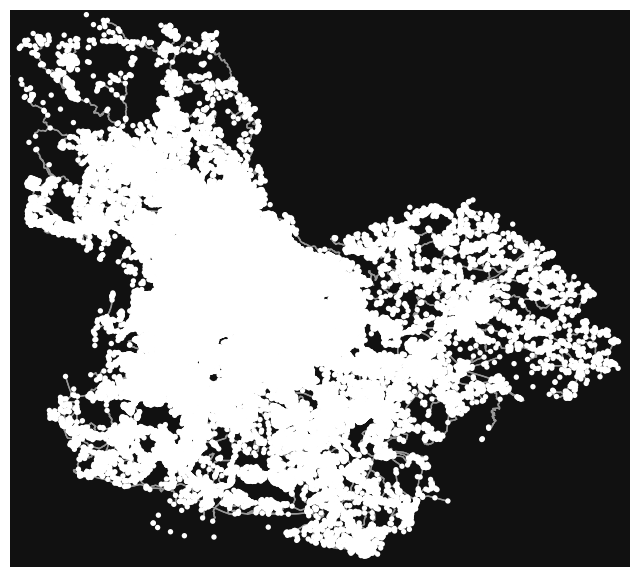

In [35]:
# Eliminar del grafo todos los links no válidos
G_snap.remove_edges_from(edges_remove)
fig, ax = ox.plot_graph(G_snap)
nodes_Gsnap, edges_Gsnap = ox.graph_to_gdfs(G_snap, nodes=True, edges=True)

In [ ]:
nodes_Gsnap.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/all_exceptWalking/Nodes/nodes_base_snap.shp')
edges_Gsnap.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/all_exceptWalking/Edges/edges_base_snap.shp')

/var/folders/8s/00_wwq9j23b09mnd7gp105m00000gp/T/ipykernel_14769/2003087300.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes_Gsnap.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/all_exceptWalking/Nodes/nodes_base_snap.shp')
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


## __Snap BusStops to Link from G_snap__

In [36]:
# 1) Reproyectar G_snap de 4326 a 32613 (metros)
print("original G_snap CRS:", G_snap.graph['crs'])
G_snap = ox.project_graph(G_snap, to_crs="EPSG:32613")
print("G_snap CRS after reprojection:", G_snap.graph['crs'])

original G_snap CRS: epsg:4326
G_snap CRS after reprojection: EPSG:32613


In [37]:
# Valores de highway que se van a considerar para el snapping
nodes_Gsnap, edges_Gsnap = ox.graph_to_gdfs(G_snap, nodes=True, edges=True)
edges_Gsnap_exploded = edges_Gsnap.explode('highway')
edges_Gsnap_exploded["highway"].value_counts()

highway
residential       268547
service            70337
living_street      48919
tertiary           27911
unclassified       14130
secondary          10093
primary             7615
trunk               1416
primary_link         780
tertiary_link        737
trunk_link           564
secondary_link       510
motorway_link        492
motorway             372
Name: count, dtype: int64

In [38]:
edges_Gsnap['highway'] = edges_Gsnap['highway'].apply(parse_highway)
edges_Gsnap.reset_index(inplace=True)

In [61]:
link_hierarchy = [
    'motorway', 'motorway_link',
    'trunk', 'trunk_link',
    'primary', 'primary_link',
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
    'unclassified',
    'residential',
    'service',
    'living_street',
]
nearest_link_id = []
nearest_u = []
nearest_v = []
snapping_distance = []
relative_position = []
nearest_highway = []

# Para cada parada
for stop in bus_stops.itertuples():
    # 1) Crear un buffer de 16m y encontrar los edges que intersectan ese buffer
    bus_stop_buffer = stop.geometry.buffer(16) #16m
    candidate_edges = edges_Gsnap[
        edges_Gsnap.geometry.intersects(bus_stop_buffer)
    ].copy()

    # 2) Si no hay edges intersectando el buffer, asignar None.
    if candidate_edges.empty:
        print(f"STOP {stop.id} sin match. No edges intersectan el buffer de 16m.")
        nearest_link_id.append(None)
        nearest_u.append(None)
        nearest_v.append(None)
        snapping_distance.append(None)
        nearest_highway.append(None)
        relative_position.append(None)
        continue

    # 3) Encontrar distancia de cada edge candidato a la parada y ordenarlos por distancia
    if not candidate_edges.empty:
        candidate_edges['snap_dist'] = candidate_edges.geometry.apply(lambda g: stop.geometry.distance(g))
        candidate_edges = candidate_edges.sort_values('snap_dist')

    selected_edge = None

    # 4) Si hay edges en el buffer, aplicar jerarquía
    for highway_type in link_hierarchy:
        # Busca edges donde 'highway' sea igual o contenga hwy_type
        mask = candidate_edges['highway'].apply(
            lambda h: highway_type in h if isinstance(h, list) else highway_type == h
        )
        filtered_edges = candidate_edges[mask]
        if not filtered_edges.empty:
            selected_edge = filtered_edges.iloc[0]  # Selecciona el edge más cercano de ese tipo
            break

    # 4) Si se encontró un edge seleccionado, agregarlo a las listas
    if selected_edge is not None:
        nearest_link_id.append(selected_edge['osmid'])
        nearest_u.append(selected_edge['u'])
        nearest_v.append(selected_edge['v'])
        snapping_distance.append(stop.geometry.distance(selected_edge.geometry))
        nearest_highway.append(selected_edge['highway'])

        # Proyecta el punto sobre la línea
        line = selected_edge.geometry
        point = stop.geometry
        proj_dist = line.project(point)
        total_length = line.length
        rel_pos = proj_dist / total_length if total_length > 0 else None
        relative_position.append(rel_pos)
    else:
        print(f"STOP {stop.id} sin match. Candidates:")
        for h in candidate_edges['highway']:
            print(f"  {h!r} (type: {type(h)})")
        nearest_link_id.append(None)
        nearest_highway.append(None)
        nearest_u.append(None)
        nearest_v.append(None)
        snapping_distance.append(None)
        relative_position.append(None)
    #print(f"Parada ID: {stop.id}, # of candidate links: {len(candidate_edges)}")

bus_stops['LinkOSMID'] = nearest_link_id
bus_stops['fromNode'] = nearest_u
bus_stops['toNode'] = nearest_v
bus_stops['Snap_Dist'] = snapping_distance
bus_stops['NearestHighway'] = nearest_highway
bus_stops['RelativePosition'] = relative_position


STOP 503.0 sin match. No edges intersectan el buffer de 16m.
STOP 1403.0 sin match. No edges intersectan el buffer de 16m.
STOP 1408.0 sin match. No edges intersectan el buffer de 16m.
STOP 1411.0 sin match. No edges intersectan el buffer de 16m.
STOP 1415.0 sin match. No edges intersectan el buffer de 16m.
STOP 1425.0 sin match. No edges intersectan el buffer de 16m.
STOP 1426.0 sin match. No edges intersectan el buffer de 16m.
STOP 1592.0 sin match. No edges intersectan el buffer de 16m.
STOP 1600.0 sin match. No edges intersectan el buffer de 16m.
STOP 1885.0 sin match. No edges intersectan el buffer de 16m.
STOP 1998.0 sin match. No edges intersectan el buffer de 16m.
STOP 2523.0 sin match. No edges intersectan el buffer de 16m.
STOP 2542.0 sin match. No edges intersectan el buffer de 16m.
STOP 4602.0 sin match. No edges intersectan el buffer de 16m.
STOP 5424.0 sin match. No edges intersectan el buffer de 16m.
STOP 5600.0 sin match. No edges intersectan el buffer de 16m.
STOP 5609

In [58]:
len(bus_stops)

12518

In [59]:
bus_stops['fromNode'] = bus_stops['fromNode'].map(node_no_map)
bus_stops['toNode'] = bus_stops['toNode'].map(node_no_map)
bus_stops

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,dicts,geometry,XCoord,YCoord,LinkOSMID,fromNode,toNode,Snap_Dist,NearestHighway,RelativePosition
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,None,POINT (680976.456 2272736.641),680976.456130,2.272737e+06,702909567,3304.0,30379.0,8.207127,[secondary],0.116142
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,None,POINT (681483.254 2280845.501),681483.253691,2.280846e+06,676886947,1495.0,2340.0,8.441228,[primary],0.817699
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,ETP/MPPTP-300,POINT (700561.553 2281164.022),700561.553323,2.281164e+06,905283410,24811.0,24808.0,6.982640,[residential],0.149949
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,ETP/MPPTP-300,POINT (700707.084 2281320.114),700707.084499,2.281320e+06,188992283,2947.0,30220.0,10.527186,[secondary],0.339513
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,ETP/MPPTP-300,POINT (700907.289 2281378.235),700907.289266,2.281378e+06,162787481,2997.0,2948.0,4.600218,[secondary],0.595657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,ETP/MPPTP-300,POINT (699396.25 2280168.108),699396.250113,2.280168e+06,937370922,18239.0,18245.0,8.663037,[primary],0.110336
12514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,ETP/MPPTP-300,POINT (699836.994 2280555.417),699836.994172,2.280555e+06,937343585,18255.0,25555.0,1.691836,[primary],0.920860
12515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,ETP/MPPTP-300,POINT (701461.661 2281478.528),701461.660841,2.281479e+06,238377764,2957.0,2959.0,2.215223,[secondary],0.801377
12516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,ETP/MPPTP-300,POINT (701108.581 2281835.306),701108.581247,2.281835e+06,162787504,3047.0,3072.0,5.281715,[tertiary],0.772637


In [60]:
# --- Asignar LinkNo a cada parada usando fromNode y toNode ---

before = len(bus_stops)

tmp = bus_stops.merge(
    visum_links[['FromNodeNo', 'ToNodeNo', 'LinkNo']],
    left_on=['fromNode', 'toNode'], 
    right_on=['FromNodeNo', 'ToNodeNo'], 
    how='left'
)

after = len(tmp)
print(f"rows before: {before}, after merge: {after}, delta: {after-before}")

bus_stops = bus_stops.merge(
    visum_links[['FromNodeNo', 'ToNodeNo', 'LinkNo']],
    left_on=['fromNode', 'toNode'], right_on=['FromNodeNo', 'ToNodeNo'], how='left'
)

dups_right = (
    visum_links.groupby(['FromNodeNo', 'ToNodeNo'])
    .size()
    .reset_index(name='n')
    .query('n > 1')
)
print(f"keys duplicadas en visum_links: {len(dups_right)}")


#columns_to_int = ['fromNode', 'toNode', 'NearestLinkID']
#bus_stops[columns_to_int] = bus_stops[columns_to_int].fillna(0).astype('int')


rows before: 12518, after merge: 12571, delta: 53
keys duplicadas en visum_links: 5660


In [50]:
bus_stops

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,geometry,XCoord,YCoord,LinkOSMID,fromNode,toNode,Snap_Dist,NearestHighway,RelativePosition,NearestLinkID
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,POINT (680976.456 2272736.641),680976.456130,2.272737e+06,702909567,3304,30379,8.207127,[secondary],0.116142,9238
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,POINT (681483.254 2280845.501),681483.253691,2.280846e+06,676886947,1495,2340,8.441228,[primary],0.817699,4352
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,POINT (700561.553 2281164.022),700561.553323,2.281164e+06,905283410,24811,24808,6.982640,[residential],0.149949,65252
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,POINT (700707.084 2281320.114),700707.084499,2.281320e+06,188992283,2947,30220,10.527186,[secondary],0.339513,8267
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,POINT (700907.289 2281378.235),700907.289266,2.281378e+06,162787481,2997,2948,4.600218,[secondary],0.595657,8384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,POINT (699396.25 2280168.108),699396.250113,2.280168e+06,937370922,18239,18245,8.663037,[primary],0.110336,49413
13309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,POINT (699836.994 2280555.417),699836.994172,2.280555e+06,937343585,18255,25555,1.691836,[primary],0.920860,49451
13310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,POINT (701461.661 2281478.528),701461.660841,2.281479e+06,238377764,2957,2959,2.215223,[secondary],0.801377,8288
13311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,POINT (701108.581 2281835.306),701108.581247,2.281835e+06,162787504,3047,3072,5.281715,[tertiary],0.772637,8511


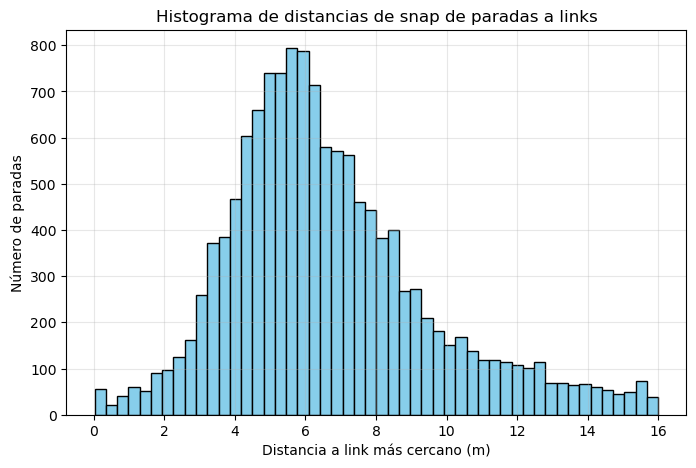

In [51]:
# Histograma de distancias de snap (en metros)
plt.figure(figsize=(8, 5))
plt.hist(bus_stops["Snap_Dist"], bins=50, color='skyblue', edgecolor='black',)
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("Histograma de distancias de snap de paradas a links")
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
bus_stops.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/buffer_and_hierarchy/bus_stops_snapped_buffer16.shp')

/var/folders/8s/00_wwq9j23b09mnd7gp105m00000gp/T/ipykernel_1259/2178632626.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  bus_stops.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/buffer_and_hierarchy/bus_stops_snapped_buffer16.shp')
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestHighway' to 'NearestHig'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'RelativePosition' to 'RelativePo'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestLinkID' to 'NearestLin'
  ogr_write(
